# Figures 15 and 16: how robust is branch selection to the sparsity strength?

This notebook reproduces the two $\lambda_{\max}$ sweep panels of the supporting-figures
appendix (App. F 1 and F 3): `Fig_lambdamax_equivariant.pdf` (Fig. 15, the rotationally
invariant, $C_4$-equivariant network) and `Fig_lambdamax_nonequivariant.pdf` (Fig. 16, the
unconstrained one). The notebook's file name predates the final figure numbering.

### The question

The L1 penalty on the bottleneck activations is what turns TetrisCNN from an ordinary
CNN into a model-selection device. Each branch $k$ carries its own coefficient
$\lambda_k$, interpolating log-linearly between $\lambda_{\min}$ and $\lambda_{\max}$
with the number of active sites in the branch's pattern, so a higher-order correlator
has to earn its place against a stiffer penalty.

That raises an obvious worry: if $\lambda_{\max}$ is a free hyperparameter, is the
"discovered" set of correlators merely a consequence of where it was set? The sweep
answers that. Across several decades of $\lambda_{\max}$ the surviving set stops
changing while the classification accuracy stays essentially flat, so the selected
representation is a property of the data and the task rather than of the knob.

That flatness is the expected behavior, not an anomaly. Many representations of very
different complexity solve the task equally well, and sparsity is what picks the
simplest of them. Accuracy is therefore the wrong quantity to watch when tuning
$\lambda_{\max}$; the activation pattern in panels (a,b) is the informative one.

### What it reads

Sweep folders under `Plots_data/sweeps/`, one per (architecture, dataset) pair. Each
holds the sweep-level `metrics_per_lambda.json` together with one representative seed's
`config.json`, which supplies the kernel set and the equivariance flag needed to draw
the branch legend. They are copies taken out of the gitignored `logs/` tree; see
`Plots_data/README.md` for how each was produced.

Results are averaged over ten random initializations, so the error bands are the
standard error across seeds, not across snapshots.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE
from tetriscnn.utils import AttrDict, load_json, DEVICE, kernel_to_latex_pattern

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tetriscnn.colors import colors, COLORS

plt.style.use(PAPER_MPLSTYLE)

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Loading helpers

A training run records everything needed to reinterpret it later: `config.json` holds
the full configuration, `metrics.json` the per-epoch history of a single run, and
`metrics_per_lambda.json` the sweep-level aggregate. The two loaders below read them
back into the same `AttrDict` the training code uses.

The one subtlety is the stride-compatibility fix. Kernel specifications gained a fifth
element (the stride) after some of these runs were recorded, so a kernel list loaded
from an older `config.json` is padded back to the current length. Without it, the
branch-drawing code below would fail on exactly the runs this figure needs.


In [2]:
def _load_config_from_folder(seed_folder: Path) -> AttrDict:
    """Load config.json from a seed-level folder and return a populated AttrDict.

    Applies the stride-compatibility fix for kernels.
    Sets cf.logdir to the seed folder path.
    """
    cfg_path = seed_folder / "config.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"No config.json found in {seed_folder}")

    cf = AttrDict()
    cf.update(load_json(str(seed_folder), "config.json"))

    # Compatibility fix for kernels without stride specified (legacy runs)
    for k in range(len(cf.kernels)):
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)

    cf.logdir = str(seed_folder)
    return cf

In [3]:
def _load_metrics_from_folder(seed_folder: Path, per_lambda=False):
    """Load metrics.json from a seed-level folder
    """
    if not per_lambda:
        cfg_path = seed_folder / "metrics.json"
        if not cfg_path.exists():
            raise FileNotFoundError(f"No metrics.json found in {seed_folder}")

        metrics = load_json(str(seed_folder), "metrics.json")
    else:
        cfg_path = seed_folder / "metrics_per_lambda.json"
        if not cfg_path.exists():
            raise FileNotFoundError(f"No metrics_per_lambda.json found in {seed_folder}")

        metrics = load_json(str(seed_folder), "metrics_per_lambda.json")
    return metrics

## Aggregating a sweep across seeds

`_aggregate` reshapes the recorded metrics into a dictionary keyed by
$\lambda_{\max}$, handling both layouts the training code has produced: one where the
sweep file stores per-seed entries directly, and one where the seeds sit a level
deeper. `_mean_ste` then reduces each quantity across seeds to a mean and a standard
error.

Branch activations are normalized before they are plotted. The absolute scale of $z_k$
carries no meaning on its own, since a branch's activation and the readout weight that
consumes it can trade off against each other. What the figure is about is which
branches stay up and which collapse, relative to one another.


In [4]:
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ── shared helpers (defined once, used by both models) ────────────────────────
def _mean_ste(arr):
    arr = np.array(arr)
    return arr.mean(axis=0), arr.std(axis=0, ddof=1) / np.sqrt(len(arr))

def _aggregate(metrics_dict, cf):
    """Aggregate per-lambda metrics into a results dict keyed by float lambda."""
    lambdas_str = list(metrics_dict.keys())
    lambdas     = np.array([float(k) for k in lambdas_str])
    results = {}
    try:
        metrics_dict[lambdas_str[0]]["z"]
    except KeyError:
        from collections import defaultdict

        result = defaultdict(lambda: defaultdict(list))

        for lam, seeds in metrics_dict.items():
            for seed, metrics in seeds.items():
                for metric, value in metrics.items():
                    result[lam][metric].append(value)

        metrics_dict = {lam: dict(metrics) for lam, metrics in result.items()}

    for lam, lam_str in zip(lambdas, lambdas_str):
        r = {}
        z = np.abs(np.array(metrics_dict[lam_str]["z"]).squeeze())
        z = z / z.max(axis=1, keepdims=True)
        r["z"], r["z_ste"] = _mean_ste(z)

        if "val_r2agg" in metrics_dict[lam_str]:
            r2 = np.array(metrics_dict[lam_str]["val_r2agg"])
            r["r2agg"], r["r2agg_ste"] = _mean_ste(r2)

        if "val_MSE" in metrics_dict[lam_str]:
            mse = np.array(metrics_dict[lam_str]["val_MSE"])
            r["val_MSE"], r["val_MSE_ste"] = _mean_ste(mse)

        if "val_CEL" in metrics_dict[lam_str]:
            cel = np.array(metrics_dict[lam_str]["val_CEL"])
            r["val_CEL"], r["val_CEL_ste"] = _mean_ste(cel)

        if "val_acc" in metrics_dict[lam_str]:
            acc = np.array(metrics_dict[lam_str]["val_acc"])
            r["val_acc"], r["val_acc_ste"] = _mean_ste(acc)

        if "pt" in metrics_dict[lam_str]:
            deriv = np.array([x for x, _ in metrics_dict[lam_str]["pt"]])
            peak  = np.array([y for _, y in metrics_dict[lam_str]["pt"]])
            r["pt_deriv"], r["pt_deriv_ste"] = _mean_ste(deriv)
            r["pt"],       r["pt_ste"]       = _mean_ste(peak)

        results[lam] = r
    return lambdas, results

def _stack(results, lambdas, metric):
    try:
        return np.array([results[lam][metric] for lam in lambdas])
    except KeyError:
        return None

def _draw_panels(axs, results, lambdas, cf, active, pt_label, deriv_label,
                 show_legend=True, titles=None, title_loc="left", supress_titles=False, colors = None):
    """Draw active metric panels into the provided axes column.

    Parameters
    ----------
    show_legend : bool
        Whether to draw the per-kernel legend on the z panel.
    titles : list[str] | None
        Override panel titles (one per active panel). None keeps defaults.
    title_loc : str
        Matplotlib title loc: "left", "center", or "right".
        Pass "inside" to place the title as an in-axes text at the top-left.
    """
    norm_pt = None
    legend_handles = []

    for i, m in enumerate(active):
        ax   = axs[i]
        mean = _stack(results, lambdas, m["name"])
        ste  = _stack(results, lambdas, m["name"] + "_ste")

        if mean is None:
            ax.axis("off")
            continue

        mean = mean.squeeze()
        if ste is not None:
            ste = ste.squeeze()

        if m.get("per_kernel"):
            for k in range(mean.shape[1]):
                label = kernel_to_latex_pattern(cf.kernels[k], full_latex=True)
                if colors is not None:
                    color = colors[k % len(colors)]
                    ln, = ax.plot(lambdas, 
                                mean[:, k], 
                                "o-", 
                                label=label,
                                color=color,
                                )
                else:
                    ln, = ax.plot(lambdas, 
                                mean[:, k], 
                                ".-", 
                                label=label)
                    
                legend_handles.append(ln)

                if ste is not None and colors is not None:
                    ax.fill_between(lambdas, 
                                    mean[:, k] - ste[:, k],
                                    mean[:, k] + ste[:, k], 
                                    color=color,
                                    alpha=0.3)
                elif ste is not None:
                    ax.fill_between(lambdas, mean[:, k] - ste[:, k],
                                    mean[:, k] + ste[:, k], alpha=0.3)
            if show_legend:
                legend = ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", ncol=2, fontsize=8)
                for txt, ln in zip(legend.get_texts(), legend.get_lines()):
                    txt.set_color(ln.get_color())

        elif m.get("heatmap"):
            if norm_pt is None:
                norm_pt = Normalize(vmin=mean.min(), vmax=mean.max())
            im = ax.imshow(mean.T, aspect="auto", cmap="viridis",
                           interpolation="nearest",
                           extent=[lambdas[0], lambdas[-1], 0, 1],
                           origin="lower", norm=norm_pt)
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="3%", pad=0.05)
            ax.get_figure().colorbar(im, cax=cax).set_label(deriv_label)
            ax.set_yticks([])
            ax.grid(False)

        else:
            color = m.get("color", "0.3")
            ax.plot(lambdas, mean, "o-", color=color)
            if ste is not None:
                ax.fill_between(lambdas, mean - ste, mean + ste, alpha=0.3, color=color)
            ax.grid(True)

        if not supress_titles:
            panel_title = titles[i] if titles is not None else m["title"]
            if title_loc == "inside":
                ax.text(0.02, 0.97, panel_title, transform=ax.transAxes,
                        fontsize=9, va="top", ha="left")
            else:
                ax.set_title(panel_title, loc=title_loc)
        ax.set_ylabel(m["ylabel"], labelpad=10)


    axs[-1].set_xlabel(r"$\log_{10}\lambda_{\max}$")
    axs[-1].set_xticks(lambdas)
    axs[-1].set_xticklabels([rf"${lam:g}$" for lam in lambdas])

    return legend_handles  # caller can place a figure-level legend

## The $\lambda_{\max}$ sweep figure, drawn for both architectures

The figure is one two-column layout drawn twice, once per architecture, so the
equivariant and unconstrained results can be compared panel for panel. `SWEEPS` names
the four sweep folders and `SAVE_NAME` the two output files.

Reading the result: for the Ising data a single $1\times1$ branch survives once
$\lambda_{\max}$ passes roughly $10^{-1}$, which is the one-dimensional representation
the main text builds on. For the XY data three branches survive in the equivariant
network and five in the unconstrained one, the extra two being separate rotational
variants of patterns the equivariant network already covers with a single weight-tied
branch. The value used throughout the paper, $\lambda_{\max} = 10^3$, sits well inside
the stable region in both cases.


In [5]:
# Figs. 15 and 16 are the same panel drawn for BOTH architectures: the C4-equivariant
# branches (saved as Fig_lambdamax_equivariant) and the plain ones
# (Fig_lambdamax_nonequivariant). Each sweep folder holds the sweep-level
# metrics_per_lambda.json plus one representative seed's config.json (kernel set,
# equivariance flag); copied out of the gitignored logs/ tree -- see
# Plots_data/README.md.
SWEEPS = {
    "C4": {
        "ising": "Plots_data/sweeps/Ising_C4_smallkernels_partition",
        "xy":    "Plots_data/sweeps/XY_XZ_C4_smallkernels_partition",
    },
    "plain": {
        "ising": "Plots_data/sweeps/Ising_plain_smallkernels_partition",
        "xy":    "Plots_data/sweeps/XY_XZ_plain_smallkernels_partition",
    },
}
SAVE_NAME = {"C4": "Fig_lambdamax_equivariant", "plain": "Fig_lambdamax_nonequivariant"}


def load_sweep(tag):
    """metrics_per_lambda + a representative config for both models of one architecture."""
    out = {}
    for model, folder in SWEEPS[tag].items():
        folder = Path(folder)
        metrics = _load_metrics_from_folder(folder, per_lambda=True)
        cf = _load_config_from_folder(folder)
        lambdas, results = _aggregate(metrics, cf)
        out[model] = {"lambdas": lambdas, "results": results, "cf": cf}
    return out


# Which panels the sweep figure shows (branch activations + validation accuracy).
enabled_metrics = {"z", "val_acc"}
pt_label    = r"$\delta$"
deriv_label = r"$d\hat\delta/d\delta$"
metrics_to_plot = [
    dict(name="z",       ylabel=r"$z\,\left[P\right]_{\rm norm}$", title="branch activations", per_kernel=True),
    dict(name="val_acc", ylabel=r"$\mathrm{Acc}$",                   title=r"validation Accuracy"),
]
active = [m for m in metrics_to_plot if enabled_metrics is None or m["name"] in enabled_metrics]

wrote Plots/Fig_lambdamax_equivariant.pdf  and  Plots/SVG/Fig_lambdamax_equivariant.svg


wrote Plots/Fig_lambdamax_nonequivariant.pdf  and  Plots/SVG/Fig_lambdamax_nonequivariant.svg


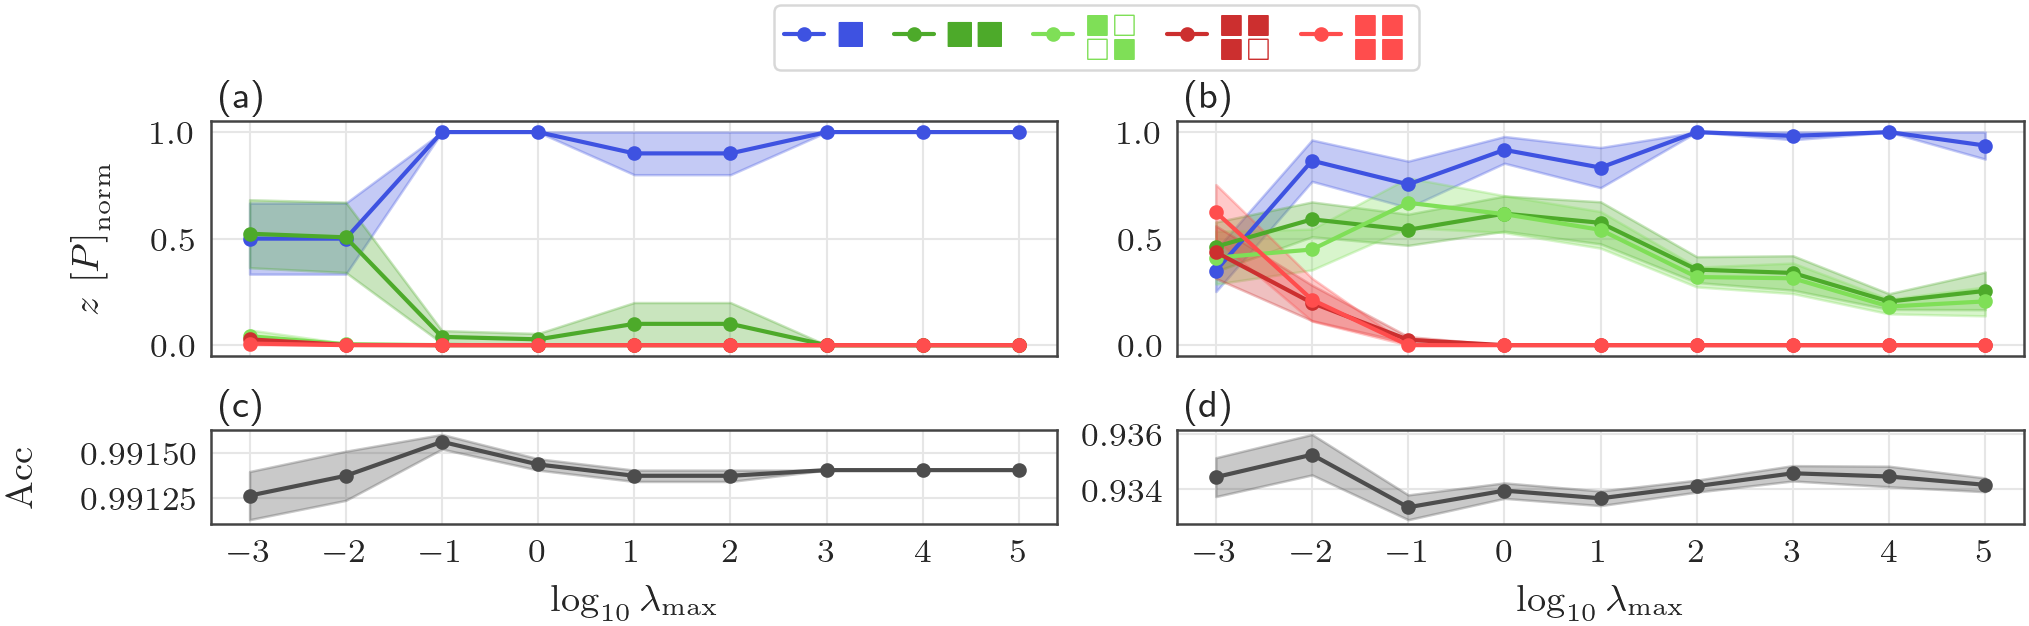

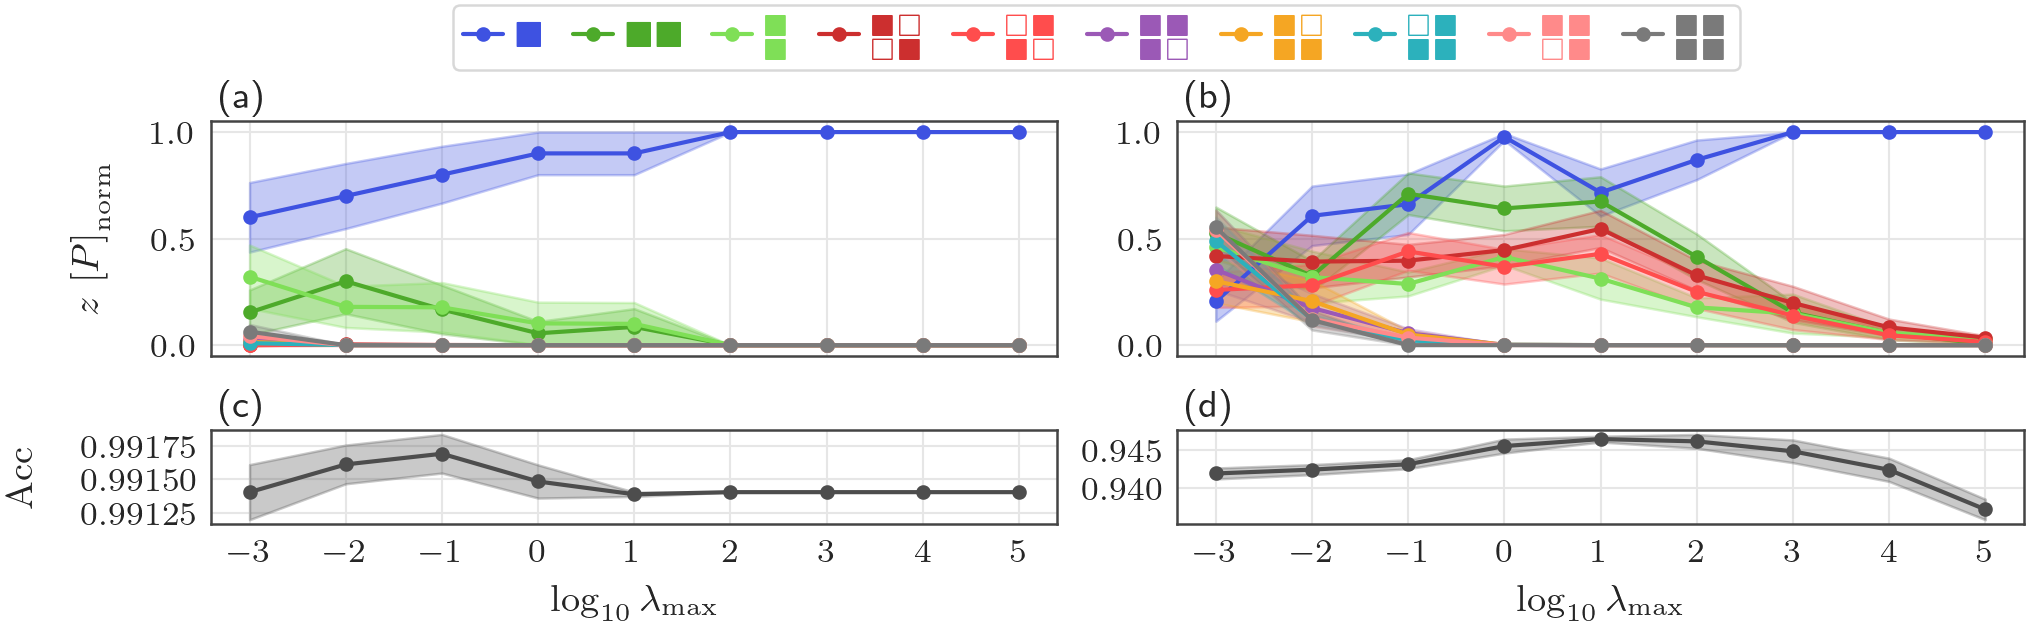

In [6]:
def make_lambdamax_figure(tag):
    """The two-column (Ising | XY) lambda-max sweep panel for one architecture."""
    data = load_sweep(tag)
    ising_lambdas, ising_results, cf_ising = (data["ising"][k] for k in ("lambdas", "results", "cf"))
    xy_lambdas,    xy_results,    cf_xy    = (data["xy"][k]    for k in ("lambdas", "results", "cf"))

    n_panels = len(active)
    DOUBLE_WIDTH = 6.80914
    golden_ratio = (1 + np.sqrt(5)) / 2
    fig_final = plt.figure(figsize=(DOUBLE_WIDTH, 0.5 * DOUBLE_WIDTH / golden_ratio))
    gs = gridspec.GridSpec(n_panels + 1, 2, figure=fig_final, height_ratios=[0.28, 1, 0.4])

    # Column order: Ising | XY XZ
    axs_col = []
    for col in range(2):
        col_axs = [fig_final.add_subplot(gs[1, col])]
        for r in range(2, n_panels + 1):
            col_axs.append(fig_final.add_subplot(gs[r, col], sharex=col_axs[0]))
        axs_col.append(col_axs)
    axs_ising, axs_xy_xz = axs_col

    legend_handles = _draw_panels(axs_xy_xz, xy_results, xy_lambdas, cf_xy,
                active, pt_label, deriv_label, show_legend=False, supress_titles=True, colors=colors)
    _draw_panels(axs_ising, ising_results, ising_lambdas, cf_ising,
                active, pt_label, deriv_label, show_legend=False, supress_titles=True, colors=colors)

    # Remove y-labels from the right column
    for ax in axs_xy_xz:
        ax.set_ylabel("")

    # Hide x-tick labels on all but the bottom row
    for col_axs in axs_col:
        for ax in col_axs[:-1]:
            plt.setp(ax.get_xticklabels(), visible=False)
            ax.set_xlabel("")

    # Figure-level per-kernel legend
    legend_labels = [kernel_to_latex_pattern(cf_ising.kernels[k], full_latex=True)
                    for k in range(len(cf_ising.kernels))]
    fig_legend = fig_final.legend(
        handles=legend_handles, labels=legend_labels,
        loc="lower center", bbox_to_anchor=(0.54, 0.865), ncol=len(legend_handles),
    )
    for txt, ln in zip(fig_legend.get_texts(), fig_legend.get_lines()):
        txt.set_color(ln.get_color())

    # Subplot labels (a)-(d), 2 columns x 2 rows
    letters = "abcd"
    ypos_per_row = [1.02, 1.05]
    xpos = 0.01
    for row_idx, row_ypos in enumerate(ypos_per_row):
        for col_idx, col_axs in enumerate(axs_col):
            letter = letters[row_idx * 2 + col_idx]
            col_axs[row_idx].text(xpos, row_ypos, f"({letter})",
                                transform=col_axs[row_idx].transAxes, va="bottom")

    return fig_final


for tag in ("C4", "plain"):
    fig_final = make_lambdamax_figure(tag)
    fig_final.savefig(f"Plots/{SAVE_NAME[tag]}.pdf")
    fig_final.savefig(f"Plots/SVG/{SAVE_NAME[tag]}.svg")
    print(f"wrote Plots/{SAVE_NAME[tag]}.pdf  and  Plots/SVG/{SAVE_NAME[tag]}.svg")